# Does the position effect shrink with model size?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AgrfhyL/audio_model_initial_testing/blob/main/Colab_ModelScaling.ipynb)

`Aug_23.ipynb` showed that on Whisper **base**, moving a short utterance later inside the 30 s
window leaves WER flat with timestamps off but quadruples it with timestamps on (0.070 -> 0.298 at
a 25 s offset), driven by a small tail of files that collapse into repetition loops.

This notebook re-runs that experiment across **model size** on a Colab GPU, to ask whether the
effect is a small-model artefact that scale removes.

|  | |
|---|---|
| models | `tiny` (39M), `base` (74M), `small` (244M), `medium` (769M) |
| corpus | 700 TIMIT `TEST` clips - the first 700 of the same seed-0 draw `Aug_23.ipynb` used |
| grid | 700 clips x 6 offsets x 2 timestamp arms x 4 models = **33 600 decodes** |
| runtime | ~2 h on a T4; resumable, results written to Drive |

## Why 700 and not 300

The effect lives almost entirely in the tail - roughly 1% of files carry ~44% of the errors at a
25 s offset - so a small subset does not just add noise, it systematically *understates* the
finding. Measured against the known 1000-clip answer:

| N | offset-25 WER (ts on) | max deviation from the full curve |
|---:|---:|---:|
| 300 | 0.2064 | 0.092 |
| 500 | 0.2471 | 0.051 |
| **700** | **0.2975** | **0.005** |
| 1000 | 0.2981 | 0 |

At 300 clips only 3 runaway files survive instead of 19, and the timestamps-off curve picks up a
spurious spike at offset 0 from a single hallucination - which would make the headline "position
is irrelevant without timestamps" look false. 700 tracks the full curve to within 0.005.

Set `N_CLIPS = 1000` below for exact comparability with `Aug_23.ipynb`, at ~40 min extra.

## 1. Colab setup

`openai-whisper` pulls in `tiktoken` and `numba`; `jiwer` is the WER scorer. `soundfile` is what
reads TIMIT's **NIST SPHERE** `.WAV` files - they are *not* RIFF/WAVE, and `scipy.io.wavfile`
cannot read them.

In [1]:
!pip -q install openai-whisper jiwer soundfile

import torch, subprocess
print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total",
                      "--format=csv,noheader"], capture_output=True, text=True).stdout.strip())
print("torch", torch.__version__, "| cuda", torch.cuda.is_available())
assert torch.cuda.is_available(), "Runtime > Change runtime type > GPU"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 15.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 88.7 MB/s eta 0:00:00
Tesla T4, 15360 MiB
torch 2.11.0+cu128 | cuda True


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 2. Locate TIMIT and the corpus spec

TIMIT lives in your Drive; the layout under `MyDrive/NAACL/timit` may or may not have an extra
`TIMIT/` level, so the `TEST` directory is located rather than assumed.

`corpus_digests.json` comes from the GitHub repo. It carries **paths and SHA-256 digests only, no
transcript text** - TIMIT is LDC93S1 and not redistributable, so the reference transcripts are
read from the `.TXT` files in *your* copy. The digests let this notebook prove it assembled
exactly the same corpus as the original experiment instead of assuming it.

In [3]:
import glob, json, os

DRIVE_ROOT   = "/content/drive/MyDrive/NAACL"
TIMIT_HINT   = os.path.join(DRIVE_ROOT, "timit")
RESULTS_CSV  = os.path.join(DRIVE_ROOT, "scaling_results.csv")   # on Drive: survives disconnects
LOCAL_AUDIO  = "/content/corpus"                                  # fast local copy

# find the TEST directory wherever it sits under the hint
cands = [d for d in glob.glob(os.path.join(TIMIT_HINT, "**", "TEST"), recursive=True)
         if os.path.isdir(os.path.join(d, "DR1"))]
assert cands, f"no TIMIT TEST/DR1 found under {TIMIT_HINT} -- check the path"
TIMIT_TEST = sorted(cands, key=len)[0]
print("TIMIT TEST:", TIMIT_TEST)

if not os.path.exists("corpus_digests.json"):
    !wget -q https://raw.githubusercontent.com/AgrfhyL/audio_model_initial_testing/main/corpus_digests.json
DIG = json.load(open("corpus_digests.json"))
print(f"corpus spec: {DIG['n_files']} files, seed {DIG['selection']['seed']}, "
      f"exclude {DIG['selection']['exclude']}")

TIMIT TEST: /content/drive/MyDrive/NAACL/timit/TIMIT/TEST
corpus spec: 1000 files, seed 0, exclude SA*


## 3. Assemble and verify the corpus

The digest file is **ordered by the original draw**, so an N-clip subset is just the first N
entries - speaker-balanced by construction, no re-derivation needed.

Each clip is copied to local disk (Drive's FUSE mount is far too slow to read 700 files six times
over), then decoded and checked against its frozen `sha256_audio`. That digest is taken over the
decoded float32 samples rather than the container bytes, so it pins the array that actually
reaches the mel.

In [4]:
import hashlib, shutil, time
import numpy as np
import soundfile as sf

N_CLIPS = 700          # 1000 for exact comparability with Aug_23.ipynb

def sha256_audio(a):
    return hashlib.sha256(np.ascontiguousarray(a, dtype=np.float32).tobytes()).hexdigest()

def load_reference(wav_path):
    '''Sibling .TXT minus the two leading sample offsets.'''
    with open(wav_path[:-4] + ".TXT") as f:
        return f.read().strip().split(None, 2)[2]

FILES, AUDIO = [], {}
t0, bad = time.time(), []
for r in DIG["files"][:N_CLIPS]:
    src = os.path.join(TIMIT_TEST, r["path"])
    dst = os.path.join(LOCAL_AUDIO, r["path"])
    if not os.path.exists(dst):
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.copy2(src, dst)
    a, sr = sf.read(dst, dtype="float32")
    if sr != DIG["sample_rate"] or len(a) != r["samples"] or sha256_audio(a) != r["sha256_audio"]:
        bad.append(r["path"]); continue
    AUDIO[r["path"]] = a
    FILES.append({**r, "reference": load_reference(src)})

assert not bad, f"{len(bad)} clips do not match the frozen digests, e.g. {bad[:3]}"
assert len(FILES) == N_CLIPS
print(f"verified + cached {len(FILES)} clips in {time.time()-t0:.0f}s "
      f"({sum(a.nbytes for a in AUDIO.values())/1e6:.0f} MB local)")
print(f"  {len({r['speaker'] for r in FILES})} speakers | "
      f"{sum(len(r['reference'].split()) for r in FILES)} reference words | "
      f"{sum(r['sec'] for r in FILES)/60:.1f} min audio")
print("  every clip byte-verified against the original experiment's corpus")

verified + cached 700 clips in 581s (132 MB local)
  168 speakers | 5518 reference words | 34.3 min audio
  every clip byte-verified against the original experiment's corpus


## 4. Controls

Held identical to `Aug_23.ipynb` except for the two things that must change on Colab:

- **`fp16=True`.** The original run was fp32 on Apple MPS. fp16 is what makes `medium` tractable
  on a T4 and is what people actually deploy. The mel is still computed in **fp32 on CPU** -
  `decode()` calls `mel.half()` itself - so the bit-identical-shift property that the whole
  experiment rests on is preserved regardless of the encoder's precision.
- **CUDA instead of MPS.** Different arithmetic, so `base` here will not reproduce `0.0705`
  exactly. That is fine and expected: this sweep is internally consistent across sizes, which is
  what a scaling comparison needs. `base` is included precisely so there is an anchor point.

### The one trap

`n_mels` is **not** always 80. `large-v3` and `turbo` use 128. `Aug_23.ipynb` hardcoded 80, which
would silently mis-shape the encoder input on those checkpoints. Here it is read from
`model.dims.n_mels` per model, so adding `large-v3` to `MODELS` needs no other change.

In [5]:
import whisper
from whisper.audio import N_SAMPLES, SAMPLE_RATE, HOP_LENGTH

MODELS    = ["tiny", "base", "small", "medium"]
OFFSETS_S = [0, 5, 10, 15, 20, 25]
OFFSETS   = [s * SAMPLE_RATE for s in OFFSETS_S]
TS_ARMS   = [True, False]
BATCH     = 16

CONTROLS = {
    "models": MODELS, "device": "cuda", "fp16": True,
    "mel": "fp32 on CPU; decode() casts to fp16 internally",
    "n_mels": "per model, from model.dims.n_mels (NOT hardcoded 80)",
    "task": "transcribe", "language": "en",
    "temperature": 0.0, "beam_size": None, "best_of": None,
    "prompt": None, "prefix": None,          # == condition_on_previous_text=False, empty prompt
    "max_initial_timestamp": 1.0,            # stock
    "padding": "zeros only (np.zeros(480000, float32))",
    "offsets_s": OFFSETS_S, "n_clips": N_CLIPS,
    "wer": "corpus-level: pooled S+D+I over pooled reference length",
}
for s, n in zip(OFFSETS_S, OFFSETS):
    assert n % HOP_LENGTH == 0
for k, v in CONTROLS.items():
    print(f"  {k:24s} {v}")

  models                   ['tiny', 'base', 'small', 'medium']
  device                   cuda
  fp16                     True
  mel                      fp32 on CPU; decode() casts to fp16 internally
  n_mels                   per model, from model.dims.n_mels (NOT hardcoded 80)
  task                     transcribe
  language                 en
  temperature              0.0
  beam_size                None
  best_of                  None
  prompt                   None
  prefix                   None
  max_initial_timestamp    1.0
  padding                  zeros only (np.zeros(480000, float32))
  offsets_s                [0, 5, 10, 15, 20, 25]
  n_clips                  700
  wer                      corpus-level: pooled S+D+I over pooled reference length


## 5. Placement and mel

Identical to the original: an exact 480000-sample zero buffer with the utterance written in at the
offset. Never `pad_or_trim`, which only right-pads and cannot express an offset.

The mel-invariance gate is re-run here on a sample rather than all 700 files - the property was
established exhaustively in `Aug_23.ipynb`, and this is a regression check that the Colab
environment reproduces it. Offsets 5-25 s must be **bit-identical**; offset 0 is expected to
differ, because `torch.stft(center=True)` reflect-pads 200 samples and at offset 0 that mirrors
the utterance's own opening instead of zeros.

In [6]:
import numpy as np
from whisper.audio import log_mel_spectrogram

def place(audio, off_samples):
    buf = np.zeros(N_SAMPLES, dtype=np.float32)
    buf[off_samples:off_samples + len(audio)] = audio
    return buf

def mel_of(audio, off_samples, n_mels):
    '''log-mel of the utterance at `off_samples`. Always CPU, always fp32.'''
    return log_mel_spectrogram(torch.from_numpy(place(audio, off_samples)), n_mels)

for r in FILES:
    for off in OFFSETS:
        assert off + r["samples"] <= N_SAMPLES, (r["path"], off)

FRAMES_PER_S, N_FRAMES = SAMPLE_RATE // HOP_LENGTH, N_SAMPLES // HOP_LENGTH
import random as _random
worst = {s: 0.0 for s in OFFSETS_S}
for r in _random.Random(7).sample(FILES, 40):
    a = AUDIO[r["path"]]
    nf = int(np.ceil(len(a) / HOP_LENGTH)) + 2
    ref = mel_of(a, 5 * SAMPLE_RATE, 80).numpy()
    for s, off in zip(OFFSETS_S, OFFSETS):
        f0 = s * FRAMES_PER_S
        n = min(nf, N_FRAMES - f0)
        worst[s] = max(worst[s], float(np.abs(
            mel_of(a, off, 80).numpy()[:, f0:f0+n] - ref[:, 500:500+n]).max()))
print("mel invariance (40-file sample):")
for s in OFFSETS_S:
    print(f"  offset {s:2d}s  worst |dev| {worst[s]:.3e}"
          + ("   <- reflect padding, expected" if s == 0 else ""))
for s in OFFSETS_S[1:]:
    assert worst[s] == 0.0, f"mel invariance FAILED at {s}s"
print("GATE PASSED: offsets 5-25 s bit-identical")

mel invariance (40-file sample):
  offset  0s  worst |dev| 5.929e-01   <- reflect padding, expected
  offset  5s  worst |dev| 0.000e+00
  offset 10s  worst |dev| 0.000e+00
  offset 15s  worst |dev| 0.000e+00
  offset 20s  worst |dev| 0.000e+00
  offset 25s  worst |dev| 0.000e+00
GATE PASSED: offsets 5-25 s bit-identical


## 6. The sweep

Model-outer, then offset, then batches of 16, decoding both timestamp arms off one mel. Each model
is loaded once and freed before the next.

Results append to `scaling_results.csv` **on Drive**, and any `(model, path, offset, arm)` already
present is skipped - so a Colab disconnect costs only the batch in flight. Re-running the cell
after a reconnect picks up where it stopped.

In [7]:
import csv, gc, time

FIELDS = ["model", "n_mels", "path", "speaker", "region", "utt", "sec",
          "offset_s", "timestamps", "text", "avg_logprob", "no_speech_prob"]

done = set()
if os.path.exists(RESULTS_CSV):
    with open(RESULTS_CSV, newline="") as f:
        for row in csv.DictReader(f):
            done.add((row["model"], row["path"], int(row["offset_s"]), row["timestamps"] == "on"))
total = len(MODELS) * len(FILES) * len(OFFSETS_S) * len(TS_ARMS)
print(f"{len(done)}/{total} cells already done")

os.makedirs(os.path.dirname(RESULTS_CSV), exist_ok=True)
new_file = not os.path.exists(RESULTS_CSV)
t_start = time.time()
with open(RESULTS_CSV, "a", newline="") as fh:
    w = csv.DictWriter(fh, fieldnames=FIELDS)
    if new_file:
        w.writeheader()

    for name in MODELS:
        if all((name, r["path"], s, t) in done
               for r in FILES for s in OFFSETS_S for t in TS_ARMS):
            print(f"{name}: complete"); continue
        t_model = time.time()
        model = whisper.load_model(name, device="cuda")
        n_mels = model.dims.n_mels                      # 80 for tiny..large-v2, 128 for v3/turbo
        opts = dict(task="transcribe", language="en", temperature=0.0, beam_size=None,
                    best_of=None, prompt=None, prefix=None, fp16=True,
                    max_initial_timestamp=1.0)
        print(f"\n{name}: {sum(p.numel() for p in model.parameters())/1e6:.0f}M params, "
              f"n_mels={n_mels}, {model.dims.n_text_layer} decoder layers")

        for s, off in zip(OFFSETS_S, OFFSETS):
            pending = [r for r in FILES
                       if any((name, r["path"], s, t) not in done for t in TS_ARMS)]
            if not pending:
                continue
            t0 = time.time()
            for i in range(0, len(pending), BATCH):
                batch = pending[i:i + BATCH]
                mel = torch.stack([mel_of(AUDIO[r["path"]], off, n_mels)
                                   for r in batch]).to("cuda")
                for ts_on in TS_ARMS:
                    if all((name, r["path"], s, ts_on) in done for r in batch):
                        continue
                    res = whisper.decode(model, mel, whisper.DecodingOptions(
                        **opts, without_timestamps=not ts_on))
                    for r, d in zip(batch, res):
                        if (name, r["path"], s, ts_on) in done:
                            continue
                        w.writerow({"model": name, "n_mels": n_mels, "path": r["path"],
                                    "speaker": r["speaker"], "region": r["region"],
                                    "utt": r["utt"], "sec": f"{r['sec']:.4f}", "offset_s": s,
                                    "timestamps": "on" if ts_on else "off",
                                    "text": d.text, "avg_logprob": f"{d.avg_logprob:.6f}",
                                    "no_speech_prob": f"{d.no_speech_prob:.6f}"})
                        done.add((name, r["path"], s, ts_on))
                fh.flush()
            print(f"  offset {s:2d}s: {len(pending)} files x 2 arms in {time.time()-t0:.0f}s")

        del model; gc.collect(); torch.cuda.empty_cache()
        print(f"  {name} done in {(time.time()-t_model)/60:.1f} min")

print(f"\nsweep complete: {len(done)} cells in {(time.time()-t_start)/60:.1f} min")
print(f"  -> {RESULTS_CSV}")

0/33600 cells already done


100%|█████████████████████████████████████| 72.1M/72.1M [00:01<00:00, 70.4MiB/s]



tiny: 37M params, n_mels=80, 4 decoder layers
  offset  0s: 700 files x 2 arms in 32s
  offset  5s: 700 files x 2 arms in 31s
  offset 10s: 700 files x 2 arms in 36s
  offset 15s: 700 files x 2 arms in 73s
  offset 20s: 700 files x 2 arms in 62s
  offset 25s: 700 files x 2 arms in 96s
  tiny done in 5.5 min


100%|████████████████████████████████████████| 139M/139M [00:01<00:00, 137MiB/s]



base: 72M params, n_mels=80, 6 decoder layers
  offset  0s: 700 files x 2 arms in 45s
  offset  5s: 700 files x 2 arms in 48s
  offset 10s: 700 files x 2 arms in 48s
  offset 15s: 700 files x 2 arms in 49s
  offset 20s: 700 files x 2 arms in 51s
  offset 25s: 700 files x 2 arms in 65s
  base done in 5.1 min


100%|███████████████████████████████████████| 461M/461M [00:08<00:00, 59.6MiB/s]



small: 241M params, n_mels=80, 12 decoder layers
  offset  0s: 700 files x 2 arms in 89s
  offset  5s: 700 files x 2 arms in 89s
  offset 10s: 700 files x 2 arms in 90s
  offset 15s: 700 files x 2 arms in 88s
  offset 20s: 700 files x 2 arms in 89s
  offset 25s: 700 files x 2 arms in 98s
  small done in 9.3 min


100%|█████████████████████████████████████| 1.42G/1.42G [00:21<00:00, 72.6MiB/s]



medium: 762M params, n_mels=80, 24 decoder layers
  offset  0s: 700 files x 2 arms in 212s
  offset  5s: 700 files x 2 arms in 208s
  offset 10s: 700 files x 2 arms in 208s
  offset 15s: 700 files x 2 arms in 207s
  offset 20s: 700 files x 2 arms in 207s
  offset 25s: 700 files x 2 arms in 207s
  medium done in 21.4 min

sweep complete: 33600 cells in 41.4 min
  -> /content/drive/MyDrive/NAACL/scaling_results.csv


## 7. Corpus WER by model and offset

Whisper's `EnglishTextNormalizer` on both sides, pooled corpus WER. The final column is the
headline scaling number: **the ratio of WER at a 25 s offset to WER at 0 s**. If scale removes the
positional sensitivity, that ratio falls towards 1 as the models get bigger.

In [8]:
from whisper.normalizers import EnglishTextNormalizer
from jiwer import process_words

normalizer = EnglishTextNormalizer()
REF = {r["path"]: normalizer(r["reference"]) for r in FILES}
rows = list(csv.DictReader(open(RESULTS_CSV, newline="")))
print(f"{len(rows)} result rows\n")

PARAMS = {"tiny": 39, "base": 74, "small": 244, "medium": 769,
          "large-v3": 1550, "turbo": 809}
summary = {}
for name in MODELS:
    for ts in ("on", "off"):
        for s in OFFSETS_S:
            sel = [r for r in rows if r["model"] == name and r["timestamps"] == ts
                   and int(r["offset_s"]) == s]
            assert len(sel) == len(FILES), f"{name}/{ts}/{s}s: {len(sel)} rows"
            summary[(name, ts, s)] = process_words(
                [REF[r["path"]] for r in sel], [normalizer(r["text"]) for r in sel]).wer

for ts in ("on", "off"):
    print(f"=== timestamps {ts.upper()} ===")
    print(f"{'model':>9}{'params':>8}" + "".join(f"{s:>8}s" for s in OFFSETS_S) + f"{'25s/0s':>9}")
    print("-" * (17 + 9 * len(OFFSETS_S) + 9))
    for name in MODELS:
        w = [summary[(name, ts, s)] for s in OFFSETS_S]
        ratio = w[-1] / w[0] if w[0] > 0 else float("nan")
        print(f"{name:>9}{PARAMS.get(name, 0):>7}M" + "".join(f"{v:>9.4f}" for v in w)
              + f"{ratio:>9.2f}x")
    print()

33600 result rows

=== timestamps ON ===
    model  params       0s       5s      10s      15s      20s      25s   25s/0s
--------------------------------------------------------------------------------
     tiny     39M   0.1025   0.1317   0.1957   0.7661   0.6604   1.4752    14.39x
     base     74M   0.0686   0.0995   0.0942   0.1180   0.1532   0.2971     4.33x
    small    244M   0.0375   0.0370   0.0530   0.0549   0.0665   0.1352     3.61x
   medium    769M   0.0235   0.0247   0.0274   0.0315   0.0375   0.0526     2.24x

=== timestamps OFF ===
    model  params       0s       5s      10s      15s      20s      25s   25s/0s
--------------------------------------------------------------------------------
     tiny     39M   0.0992   0.1011   0.1081   0.1089   0.1063   0.1059     1.07x
     base     74M   0.0839   0.0666   0.0759   0.0649   0.0658   0.0750     0.89x
    small    244M   0.0366   0.0352   0.0336   0.0345   0.0366   0.0370     1.01x
   medium    769M   0.0236   0.0231  

## 8. Figures

wrote scaling_wer_timestamps_on.png (+ copy on Drive)
wrote scaling_wer_timestamps_off.png (+ copy on Drive)


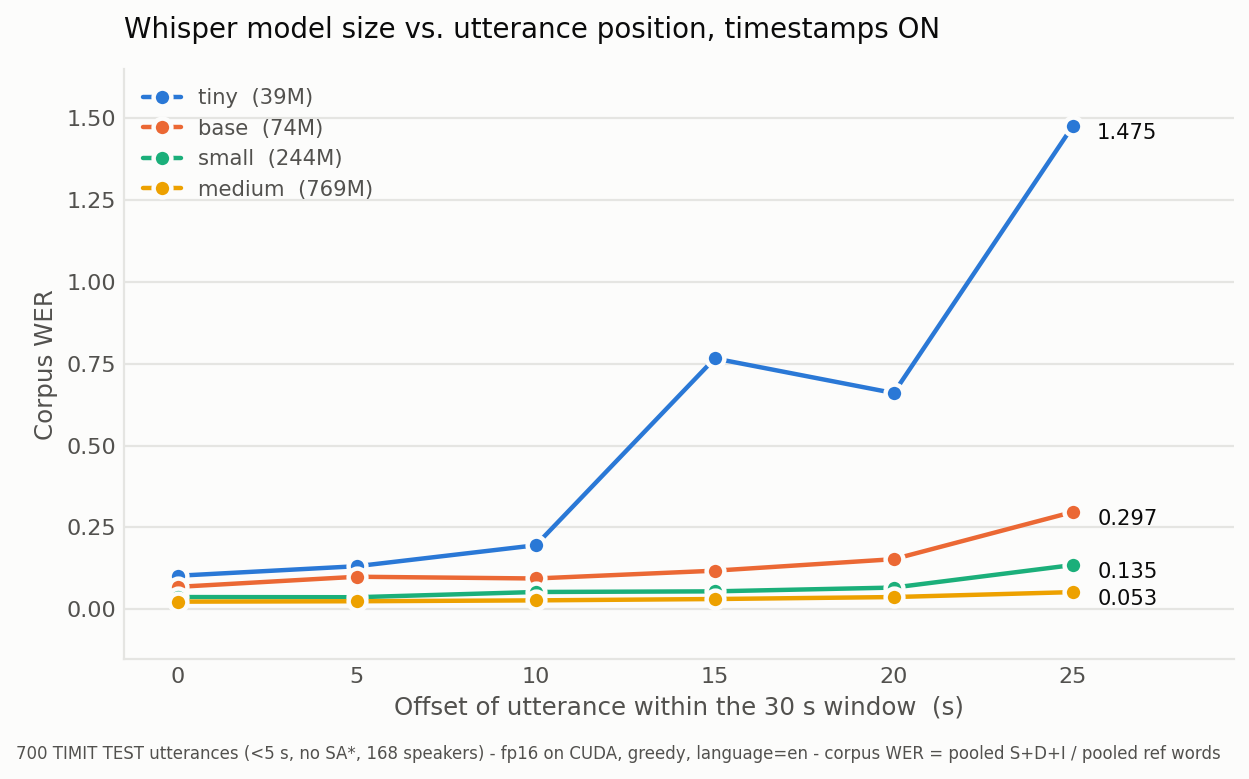

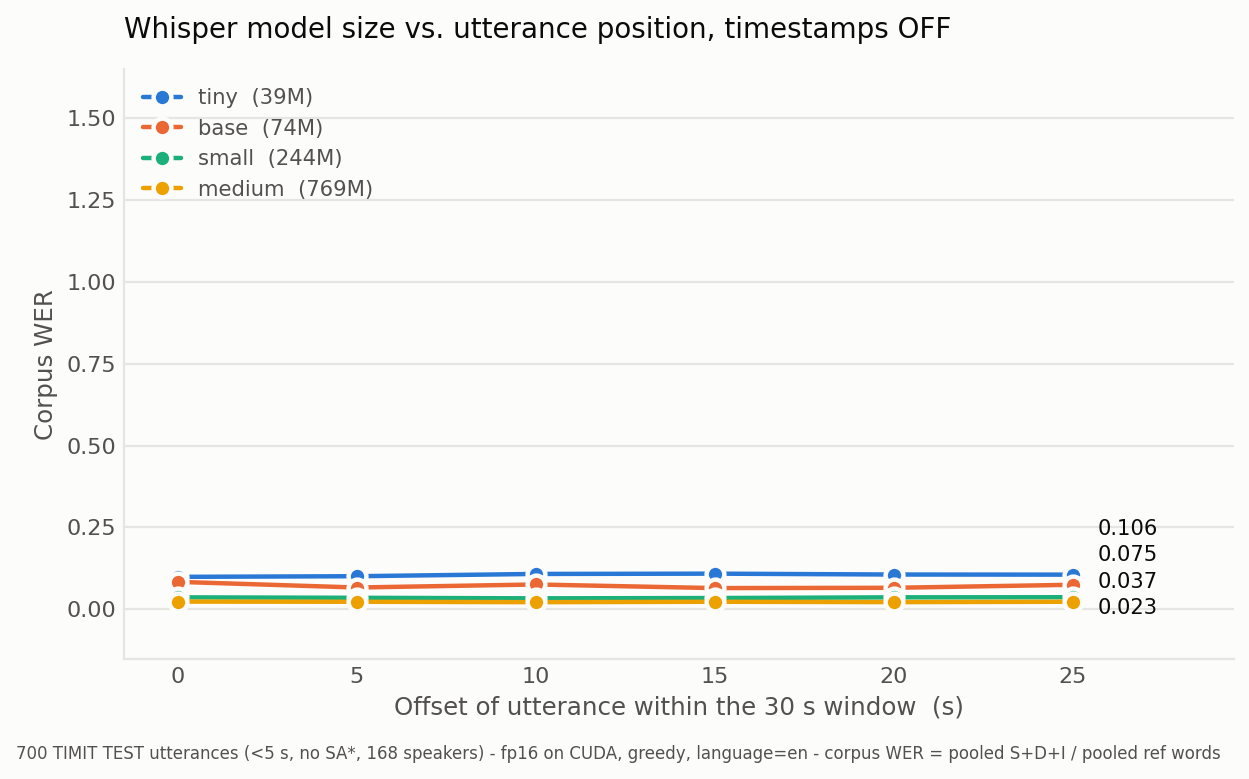

In [9]:
import matplotlib.pyplot as plt

SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e5e5e2"
# categorical slots 1-4, assigned in size order so colour follows the model, not its rank
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
COLOR = {m: PALETTE[i % len(PALETTE)] for i, m in enumerate(MODELS)}

_all = [summary[(m, ts, s)] for m in MODELS for ts in ("on", "off") for s in OFFSETS_S]
pad = max((max(_all) - min(_all)) * 0.12, 0.004)
YLIM = (min(_all) - pad, max(_all) + pad)


def plot_arm(ts, fname):
    fig, ax = plt.subplots(figsize=(7.8, 4.7), dpi=160)
    fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
    ax.grid(True, axis="y", color=GRID, linewidth=1, linestyle="-")
    ax.set_axisbelow(True)

    ends = []
    for m in MODELS:
        w = [summary[(m, ts, s)] for s in OFFSETS_S]
        ax.plot(OFFSETS_S, w, color=COLOR[m], linewidth=2, marker="o", markersize=8,
                markeredgecolor=SURFACE, markeredgewidth=2,
                label=f"{m}  ({PARAMS.get(m,0)}M)",
                solid_capstyle="round", solid_joinstyle="round", zorder=3)
        ends.append([w[-1], m])

    span = YLIM[1] - YLIM[0]                       # stagger colliding end labels
    ends.sort(key=lambda e: e[0])
    for i in range(1, len(ends)):
        if ends[i][0] - ends[i-1][0] < span * 0.045:
            ends[i][0] = ends[i-1][0] + span * 0.045
    for ypos, m in ends:
        ax.annotate(f"{summary[(m, ts, OFFSETS_S[-1])]:.3f}", (OFFSETS_S[-1], ypos),
                    textcoords="offset points", xytext=(11, -3), fontsize=9.5,
                    color=INK, va="center", annotation_clip=False)

    ax.set_ylim(*YLIM); ax.set_xticks(OFFSETS_S); ax.set_xlim(-1.5, 29.5)
    ax.set_xlabel("Offset of utterance within the 30 s window  (s)", fontsize=11, color=INK2)
    ax.set_ylabel("Corpus WER", fontsize=11, color=INK2)
    ax.set_title(f"Whisper model size vs. utterance position, timestamps {ts.upper()}",
                 fontsize=12.5, color=INK, pad=14, loc="left")
    ax.tick_params(colors=INK2, labelsize=10, length=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID); ax.spines[side].set_linewidth(1)
    leg = ax.legend(frameon=False, fontsize=9.5, loc="upper left", handlelength=1.8)
    for t in leg.get_texts():
        t.set_color(INK2)

    fig.text(0.005, -0.02,
             f"{len(FILES)} TIMIT TEST utterances (<5 s, no SA*, 168 speakers) - "
             f"fp16 on CUDA, greedy, language=en - corpus WER = pooled S+D+I / pooled ref words",
             fontsize=7.5, color=INK2)
    fig.tight_layout()
    fig.savefig(fname, bbox_inches="tight", facecolor=SURFACE)
    fig.savefig(os.path.join(DRIVE_ROOT, os.path.basename(fname)),
                bbox_inches="tight", facecolor=SURFACE)
    print(f"wrote {fname} (+ copy on Drive)")


for ts, fn in (("on", "scaling_wer_timestamps_on.png"),
               ("off", "scaling_wer_timestamps_off.png")):
    plot_arm(ts, fn)
plt.show()

## 9. Verification

In [10]:
ok = []
assert len(FILES) == N_CLIPS and len({r["path"] for r in FILES}) == N_CLIPS
ok.append(f"1. corpus: {N_CLIPS} clips, every one verified against the frozen sha256_audio")

assert all(o % HOP_LENGTH == 0 for o in OFFSETS)
assert all(o + r["samples"] <= N_SAMPLES for r in FILES for o in OFFSETS)
ok.append("2. offsets: multiples of 160, all placements fit the 30 s window")

assert all(worst[s] == 0.0 for s in OFFSETS_S[1:])
ok.append("3. mel gate: offsets 5-25 s bit-identical on the sampled files")

exp = len(MODELS) * len(FILES) * len(OFFSETS_S) * len(TS_ARMS)
assert len(rows) == exp, f"{len(rows)} rows, expected {exp}"
assert len({(r["model"], r["path"], r["offset_s"], r["timestamps"]) for r in rows}) == exp
ok.append(f"4. grid: {exp} rows, no duplicates, no gaps")

# every model used the n_mels its own checkpoint declares
seen = {r["model"]: int(r["n_mels"]) for r in rows}
for name, nm in seen.items():
    assert nm in (80, 128), (name, nm)
ok.append(f"5. n_mels taken per model from model.dims: {seen}")

for fn in ("scaling_wer_timestamps_on.png", "scaling_wer_timestamps_off.png"):
    assert os.path.getsize(fn) > 10000, fn
ok.append("6. figures: both PNGs written locally and to Drive")

for line in ok:
    print("PASS  " + line)

PASS  1. corpus: 700 clips, every one verified against the frozen sha256_audio
PASS  2. offsets: multiples of 160, all placements fit the 30 s window
PASS  3. mel gate: offsets 5-25 s bit-identical on the sampled files
PASS  4. grid: 33600 rows, no duplicates, no gaps
PASS  5. n_mels taken per model from model.dims: {'tiny': 80, 'base': 80, 'small': 80, 'medium': 80}
PASS  6. figures: both PNGs written locally and to Drive
